<a href="https://colab.research.google.com/github/YYM89/MSSP607/blob/main/Final_Consumption_code_Analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Analysis of Per Capita Consumption in China
### Optimized and Structured Notebook

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


## 1. Import Libraries

In [2]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import geopandas as gpd
from scipy import stats
from scipy.stats import shapiro, anderson
from statsmodels.stats.outliers_influence import variance_inflation_factor
import statsmodels.api as sm
import warnings
warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid')

## 2. Load Dataset

In [3]:
df = pd.read_excel('/content/drive/MyDrive/MSSP607/Data/Final Data.xlsx')
df.head()

,province,cons_pc,income_pc,urb_rate,gdp,tertiary_val,tertiary_share,pop,fiscal_exp,socexp_pc,cpi,rail_km
0,Beijing,49748,85415,0.8650,4984.31,3712.96,0.744930,21.83,839.648,38463.032524,100.1,836
1,Tianjin City,35804,53581,0.8255,1802.43,1048.62,0.581781,13.64,362.068,26544.574780,100.2,298
2,Hebei Province,24253,34665,0.4936,4752.69,2304.26,0.484833,73.78,1032.597,13995.622120,100.2,74
3,Shanxi Province,21090,32441,0.5430,2549.47,1097.96,0.430662,34.46,631.808,18334.532792,100.1,23
4,Inner Mongolia Autonomous Region,28113,40077,0.6097,2631.46,1018.61,0.387089,23.88,692.804,29011.892797,100.2,49


## 3. Descriptive Statistics

In [4]:
df.describe().round(2)

,cons_pc,income_pc,urb_rate,gdp,tertiary_val,tertiary_share,pop,fiscal_exp,socexp_pc,cpi,rail_km
count,31.00,31.00,31.00,31.00,31.00,31.00,31.00,31.00,31.00,31.00,31.00
mean,27690.06,40790.65,0.56,4323.59,2200.24,0.50,45.36,786.75,22081.97,100.21,327.71
std,8609.86,15239.46,0.13,3495.21,1833.33,0.07,30.61,388.03,12908.67,0.21,355.35
min,18983.00,26612.00,0.26,276.49,129.47,0.39,3.70,176.95,11712.82,99.70,0.00
25%,22118.00,31338.00,0.48,1927.92,942.97,0.47,24.23,585.12,14717.12,100.05,61.50
50%,24878.00,34829.00,0.54,3261.27,1582.39,0.49,39.53,692.80,17937.97,100.20,210.00
75%,28000.50,41077.00,0.61,5584.38,3105.58,0.51,63.31,992.45,23079.09,100.40,491.50
max,52722.00,88366.00,0.89,14163.38,7569.52,0.74,127.80,1795.64,78906.76,100.50,1382.00


## 4. Distribution of Per Capita Consumption

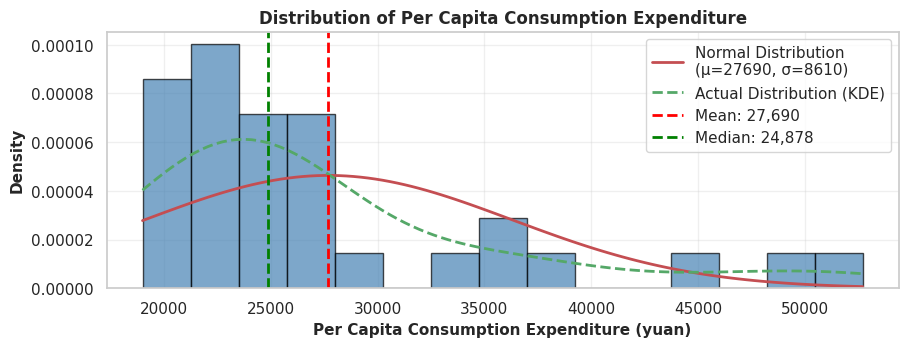

In [5]:
cons_data = df['cons_pc']
desc_stats = {
    'N': len(cons_data),
    'Mean': cons_data.mean(),
    'Median': cons_data.median(),
    'Std Dev': cons_data.std(),
    'Min': cons_data.min(),
    'Max': cons_data.max(),
    'Range': cons_data.max() - cons_data.min(),
    'CV (%)': (cons_data.std() / cons_data.mean()) * 100,
    'Q1 (25%)': cons_data.quantile(0.25),
    'Q3 (75%)': cons_data.quantile(0.75),
    'IQR': cons_data.quantile(0.75) - cons_data.quantile(0.25)
}
fig = plt.figure(figsize=(16, 12))
gs = fig.add_gridspec(3, 3, hspace=0.3, wspace=0.3)
# 1. Histogram with density curve
ax1 = fig.add_subplot(gs[0, :2])
n, bins, patches = ax1.hist(cons_data, bins=15, density=True,
                            alpha=0.7, color='steelblue', edgecolor='black')
# Add normal distribution curve
mu, sigma = cons_data.mean(), cons_data.std()
x = np.linspace(cons_data.min(), cons_data.max(), 100)
ax1.plot(x, stats.norm.pdf(x, mu, sigma), 'r-', linewidth=2,
         label=f'Normal Distribution\n(μ={mu:.0f}, σ={sigma:.0f})')
# Add actual kernel density
from scipy.stats import gaussian_kde
kde = gaussian_kde(cons_data)
ax1.plot(x, kde(x), 'g--', linewidth=2, label='Actual Distribution (KDE)')
ax1.axvline(cons_data.mean(), color='red', linestyle='--', linewidth=2,
            label=f'Mean: {cons_data.mean():,.0f}')
ax1.axvline(cons_data.median(), color='green', linestyle='--', linewidth=2,
            label=f'Median: {cons_data.median():,.0f}')
ax1.set_xlabel('Per Capita Consumption Expenditure (yuan)', fontsize=11, fontweight='bold')
ax1.set_ylabel('Density', fontsize=11, fontweight='bold')
ax1.set_title('Distribution of Per Capita Consumption Expenditure',
              fontsize=12, fontweight='bold')
ax1.legend(loc='upper right')
ax1.grid(True, alpha=0.3)

## 5. Normality Tests

In [6]:
print("Shapiro-Wilk test:", shapiro(cons_data))
print("Anderson-Darling test:", anderson(cons_data))

Shapiro-Wilk test: ShapiroResult(statistic=np.float64(0.7852254707925501), pvalue=np.float64(2.7824853365991932e-05))
Anderson-Darling test: AndersonResult(statistic=np.float64(2.4656880438798368), critical_values=array([0.522, 0.595, 0.713, 0.832, 0.99 ]), significance_level=array([15. , 10. ,  5. ,  2.5,  1. ]), fit_result=  params: FitParams(loc=np.float64(27690.064516129034), scale=np.float64(8609.858674548552))
 success: True
 message: '`anderson` successfully fit the distribution to the data.')


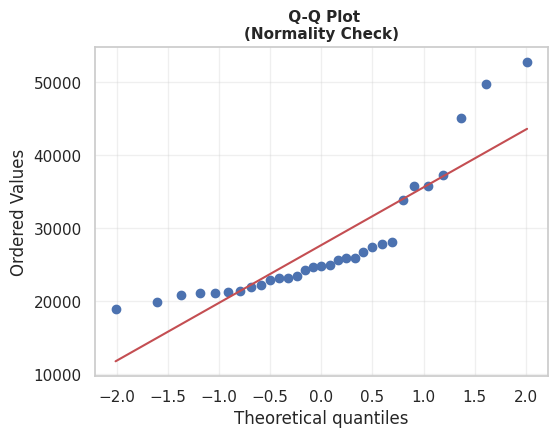

In [7]:
fig = plt.figure(figsize=(16,12))
gs = fig.add_gridspec(3, 3)
ax2 = fig.add_subplot(gs[0, 2])
stats.probplot(cons_data, dist="norm", plot=ax2)
ax2.set_title(' Q-Q Plot\n(Normality Check)', fontsize=11, fontweight='bold')
ax2.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

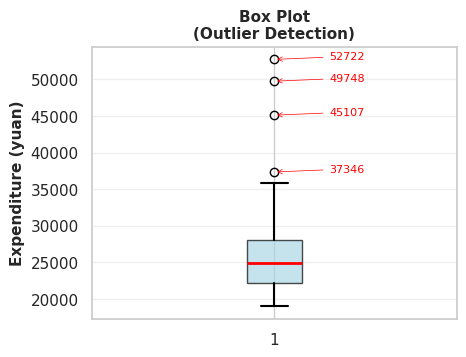

In [8]:
# IQR
Q1 = cons_data.quantile(0.25)
Q3 = cons_data.quantile(0.75)
IQR = Q3 - Q1
lower_bound_iqr = Q1 - 1.5 * IQR
upper_bound_iqr = Q3 + 1.5 * IQR

outliers_iqr = cons_data[(cons_data < lower_bound_iqr) | (cons_data > upper_bound_iqr)]
# Box Plot with outlier annotations
fig = plt.figure(figsize=(16,12))
gs = fig.add_gridspec(3, 3)
ax3 = fig.add_subplot(gs[1, 0])
bp = ax3.boxplot(cons_data, vert=True, patch_artist=True,
                 boxprops=dict(facecolor='lightblue', alpha=0.7),
                 medianprops=dict(color='red', linewidth=2),
                 whiskerprops=dict(linewidth=1.5),
                 capprops=dict(linewidth=1.5))
ax3.set_ylabel('Expenditure (yuan)', fontsize=11, fontweight='bold')
ax3.set_title('Box Plot\n(Outlier Detection)', fontsize=11, fontweight='bold')
ax3.grid(True, alpha=0.3, axis='y')
# Add outlier labels
if len(outliers_iqr) > 0:
    for outlier in outliers_iqr:
        ax3.annotate(f'{outlier:.0f}', xy=(1, outlier), xytext=(1.15, outlier),
                    fontsize=8, ha='left', color='red',
                    arrowprops=dict(arrowstyle='->', color='red', lw=0.5))
plt.show()

## 6. Geographic Visualization (Map)
*Insert your merged shapefile and mapping code here.*

In [9]:
!pip install geopandas mapclassify

In [10]:
china = gpd.read_file('/content/drive/MyDrive/MSSP607/Assignments/Final/province.shp')
print(china.columns)
china.head()

Index(['pr_adcode', 'pr_name', 'cn_adcode', 'cn_name', 'geometry'], dtype='object')


,pr_adcode,pr_name,cn_adcode,cn_name,geometry
0,110000,北京市,100000,中华人民共和国,"POLYGON ((116.89226 39.69491, 116.89227 39.694..."
1,120000,天津市,100000,中华人民共和国,"MULTIPOLYGON (((113.77712 36.63946, 113.7808 3..."
2,130000,河北省,100000,中华人民共和国,"MULTIPOLYGON (((113.56331 36.5891, 113.55296 3..."
3,140000,山西省,100000,中华人民共和国,"POLYGON ((114.04201 40.60888, 114.04441 40.611..."
4,150000,内蒙古自治区,100000,中华人民共和国,"POLYGON ((119.25798 42.22412, 119.25568 42.220..."


In [11]:
eng2chn = {
    "Beijing": "北京市",
    "Tianjin City": "天津市",
    "Hebei Province": "河北省",
    "Shanxi Province": "山西省",
    "Inner Mongolia Autonomous Region": "内蒙古自治区",
    "Liaoning Province": "辽宁省",
    "Jilin Province": "吉林省",
    "Heilongjiang Province": "黑龙江省",
    "Shanghai": "上海市",
    "Jiangsu Province": "江苏省",
    "Zhejiang Province": "浙江省",
    "Anhui Province": "安徽省",
    "Fujian Province": "福建省",
    "Jiangxi Province": "江西省",
    "Shandong Province": "山东省",
    "Henan Province": "河南省",
    "Hubei Province": "湖北省",
    "Hunan Province": "湖南省",
    "Guangdong Province": "广东省",
    "Guangxi Zhuang Autonomous Region": "广西壮族自治区",
    "Hainan": "海南省",
    "Chongqing": "重庆市",
    "Sichuan Province": "四川省",
    "Guizhou Province": "贵州省",
    "Yunnan Province": "云南省",
    "Tibet Autonomous Region": "西藏自治区",
    "Shaanxi Province": "陕西省",
    "Gansu Province": "甘肃省",
    "Qinghai Province": "青海省",
    "Ningxia Hui Autonomous Region": "宁夏回族自治区",
    "Xinjiang Uygur Autonomous Region": "新疆维吾尔自治区"
}


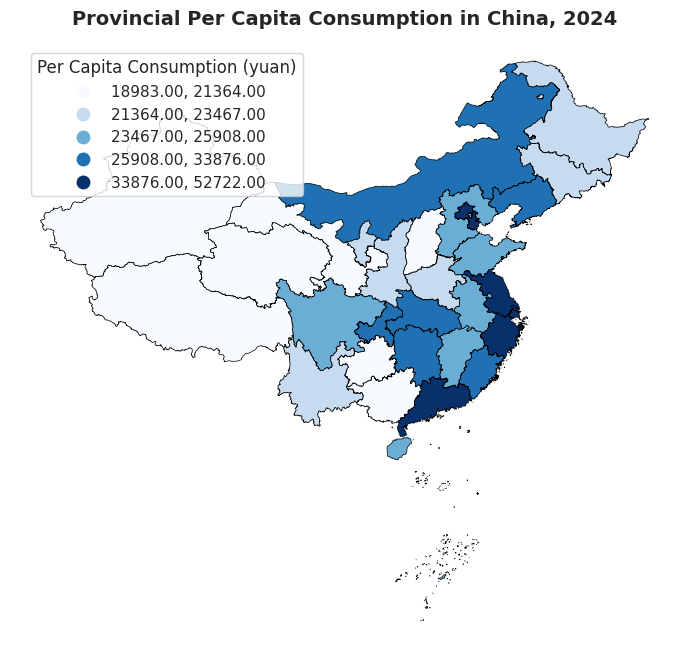

In [12]:
df['pr_name_chn'] = df['province'].map(eng2chn)
gdf = china.merge(df, left_on='pr_name', right_on='pr_name_chn', how='left')

fig, ax = plt.subplots(1, 1, figsize=(10, 8))

gdf.plot(
    column='cons_pc',
    cmap='Blues',
    scheme='Quantiles',
    k=5,
    linewidth=0.5,
    edgecolor='black',
    legend=True,
    legend_kwds={
        'title': "Per Capita Consumption (yuan)",
        'loc': 'upper left',           # 放到左上角
        'bbox_to_anchor': (0.02, 0.98) # 微调位置(越接近0越靠左/下)
    },
    ax=ax
)

ax.set_title("Provincial Per Capita Consumption in China, 2024",
             fontsize=14, fontweight='bold')
ax.axis('off')

plt.show()

## 7. Heat Map

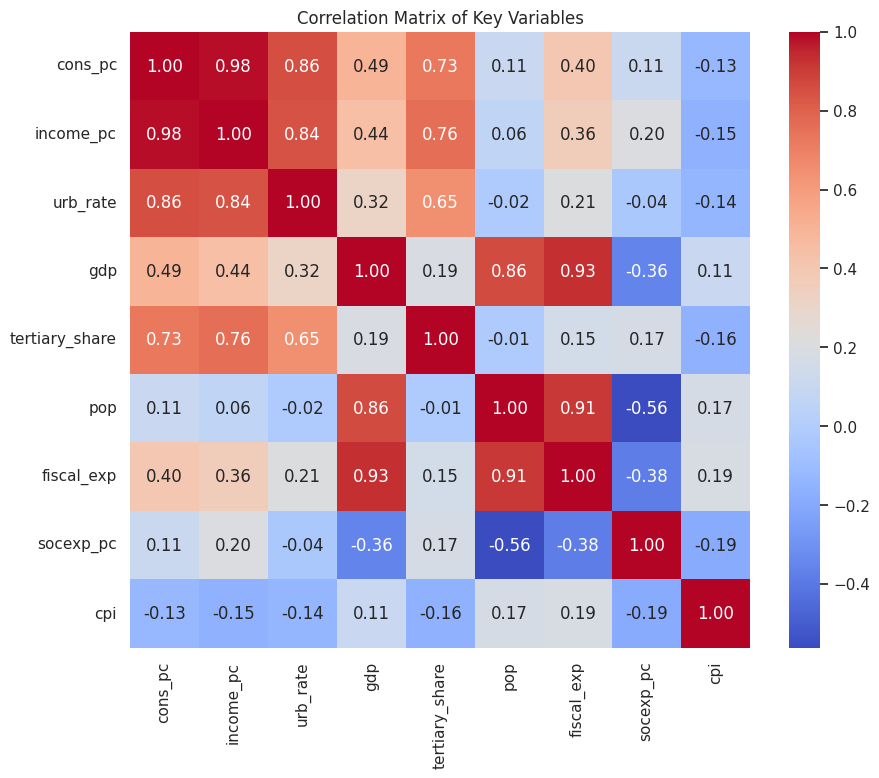

In [13]:
num_cols = ['cons_pc', 'income_pc', 'urb_rate', 'gdp',
            'tertiary_share', 'pop', 'fiscal_exp', 'socexp_pc', 'cpi']
corr = df[num_cols].corr()

plt.figure(figsize=(10, 8))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm")
plt.title("Correlation Matrix of Key Variables")
plt.show()

## 8. Multicollinearity Check (VIF)

In [14]:
features = ['income_pc','urb_rate','tertiary_share','rail_km','fiscal_exp']
X = df[features].dropna()
vif_df = pd.DataFrame()
vif_df['feature'] = features
vif_df['VIF'] = [variance_inflation_factor(X.values, i) for i in range(len(features))]
vif_df

,feature,VIF
0,income_pc,40.330545
1,urb_rate,56.771821
2,tertiary_share,48.278363
3,rail_km,7.613364
4,fiscal_exp,11.759338


##9. region + region dummies

In [15]:
# 1. region defination
east = [
    "Beijing", "Tianjin City", "Hebei Province", "Shanghai",
    "Jiangsu Province", "Zhejiang Province", "Fujian Province",
    "Shandong Province", "Guangdong Province", "Hainan"
]

central = [
    "Shanxi Province", "Anhui Province", "Jiangxi Province",
    "Henan Province", "Hubei Province", "Hunan Province"
]

west = [
    "Inner Mongolia Autonomous Region", "Guangxi Zhuang Autonomous Region",
    "Chongqing", "Sichuan Province", "Guizhou Province",
    "Yunnan Province", "Tibet Autonomous Region", "Shaanxi Province",
    "Gansu Province", "Qinghai Province", "Xinjiang Uygur Autonomous Region",
    "Ningxia Hui Autonomous Region"
]

northeast = [
    "Liaoning Province", "Jilin Province", "Heilongjiang Province"
]

def assign_region(p):
    if p in east:
        return "East"
    elif p in central:
        return "Central"
    elif p in west:
        return "West"
    elif p in northeast:
        return "Northeast"
    else:
        return "Other"

df["region"] = df["province"].apply(assign_region)

df[["province", "region"]].head()
df["region"].value_counts()


,count
region,
West,12
East,10
Central,6
Northeast,3


## 10. Regression Analysis

In [18]:
#Model
region_dummies = pd.get_dummies(df["region"], prefix="reg", drop_first=True).astype(int)
region_dummies.head()
X = pd.concat([
    df[["income_pc", "urb_rate", "tertiary_share", "rail_km", "fiscal_exp"]],
    region_dummies
], axis=1)
Y = df['cons_pc']

X = sm.add_constant(X)

model = sm.OLS(Y, X).fit()
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:                cons_pc   R-squared:                       0.978
Model:                            OLS   Adj. R-squared:                  0.970
Method:                 Least Squares   F-statistic:                     122.1
Date:                Sat, 13 Dec 2025   Prob (F-statistic):           2.02e-16
Time:                        01:03:14   Log-Likelihood:                -265.21
No. Observations:                  31   AIC:                             548.4
Df Residuals:                      22   BIC:                             561.3
Df Model:                           8                                         
Covariance Type:            nonrobust                                         
                     coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------
const           9012.5572   4127.278      2.